In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageOps,Image

In [2]:
image = cv2.imread(os.path.join('..', 'data','preprocessed_images', '201.png'))

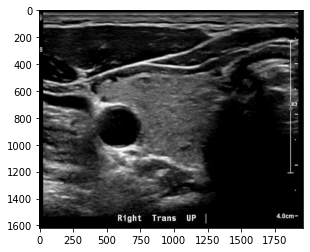

In [3]:
plt.imshow(image)

In [4]:
grey_image=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


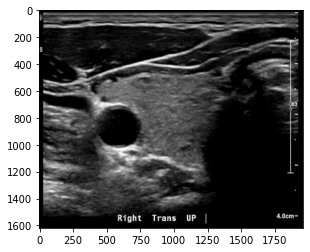

In [5]:
plt.imshow(grey_image,cmap='gray')


In [6]:
blur=cv2.GaussianBlur(grey_image,(3,3),0)


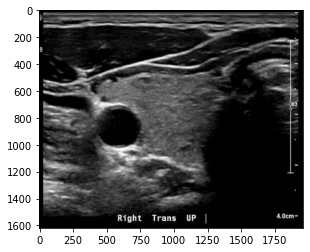

In [7]:
plt.imshow(blur,cmap='gray')


In [8]:
thresh= cv2.threshold(blur,10,255,cv2.THRESH_BINARY)[1]


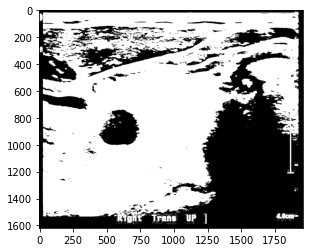

In [9]:
plt.imshow(thresh,cmap='gray')


In [10]:
kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))


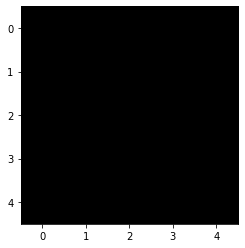

In [11]:
plt.imshow(kernel,cmap='gray')


In [12]:
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

opening=cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)

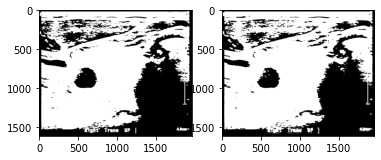

In [13]:
f, axarr = plt.subplots(1,2)
axarr[0].imshow(opening,cmap='gray')
axarr[1].imshow(closing,cmap='gray')

might have to use open/ close depending on

In [14]:
imagearray=np.array(closing)
print(imagearray)

binary_mask=np.zeros(imagearray.shape)
binary_mask[imagearray>0]=1


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [15]:
row_prop=np.mean(binary_mask,axis=0)
column_prop=np.mean(binary_mask,axis=1)
print(row_prop)
print(column_prop)

[0.06736712 0.06736712 0.05562423 ... 0.         0.         0.        ]
[0.00306122 0.00255102 0.00102041 ... 0.         0.         0.        ]


(1513, 1892)


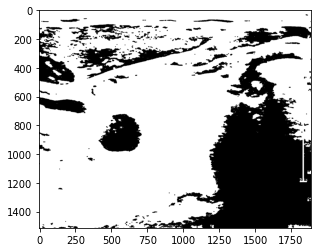

In [16]:
x_min = np.min(np.where(column_prop > 0.3))
x_max = np.max(np.where(column_prop >0.3))
y_max = np.max(np.where(row_prop > 0.5))
y_min = np.min(np.where(row_prop > 0.5))


bbox =imagearray[x_min:x_max, y_min:y_max]
print(bbox.shape)
plt.imshow(bbox,cmap='gray')

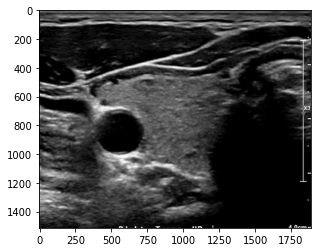

In [17]:
trimmed_image=np.array(image)[x_min:x_max, y_min:y_max]
plt.imshow(trimmed_image)

In [18]:
xpix= trimmed_image.shape[1]
ypix= trimmed_image.shape[0]
print(xpix,ypix)

xscale=1900/xpix
yscale=1400/ypix

if xscale>yscale:
    unifiedscale=yscale
else:
    unifiedscale=xscale

print (unifiedscale)

stretched_image=cv2.resize(trimmed_image, (int(xpix*unifiedscale), int(ypix*unifiedscale)))




1892 1513
0.9253139458030403


(1400, 1750, 3)


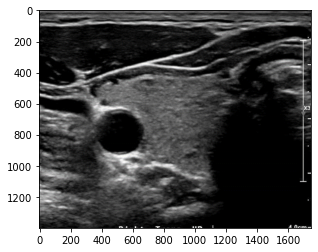

In [19]:
print(stretched_image.shape)
plt.imshow(stretched_image)

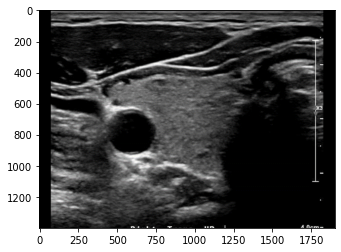

In [20]:
pil_image= Image.fromarray(stretched_image)
padded_image=ImageOps.pad(pil_image, (1900,1400), method=3, color="black", centering=(0.5, 0.5))
final_image=np.array(padded_image) 

plt.imshow(final_image)


In [21]:
def bounding_box_with_resize(sample):
    import os
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import ImageOps,Image

    image = sample

    grey_image=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur=cv2.GaussianBlur(grey_image,(3,3),0)

    thresh= cv2.threshold(blur,10,255,cv2.THRESH_BINARY)[1]

    kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    opening=cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)


    imagearray=np.array(closing)
    binary_mask=np.zeros(imagearray.shape)
    binary_mask[imagearray>0]=1

    row_prop=np.mean(binary_mask,axis=0)
    column_prop=np.mean(binary_mask,axis=1)
    
    x_min = np.min(np.where(column_prop > 0.3))
    x_max = np.max(np.where(column_prop >0.3))
    y_max = np.max(np.where(row_prop > 0.5))
    y_min = np.min(np.where(row_prop > 0.5))


    bbox =imagearray[x_min:x_max, y_min:y_max]

    trimmed_image=np.array(image)[x_min:x_max, y_min:y_max]

    xpix= trimmed_image.shape[1]
    ypix= trimmed_image.shape[0]

    xscale=1900/xpix
    yscale=1400/ypix

    if xscale>yscale:
        unifiedscale=yscale
    else:
        unifiedscale=xscale


    stretched_image=cv2.resize(trimmed_image, (int(xpix*unifiedscale), int(ypix*unifiedscale)))

    pil_image= Image.fromarray(stretched_image)
    padded_image=ImageOps.pad(pil_image, (1900,1400), method=3, color="black", centering=(0.5, 0.5))
    final_image=np.array(padded_image) 

    return final_image

